# Classification with built-in Galaxy10 network

Pipeline is inspired by [astroNN](https://github.com/henrysky/astroNN/blob/master/demo_tutorial/galaxy10/Galaxy10_Tutorial.ipynb).

In [43]:
# cd ..

In [44]:
# install requirements

# if connected to colab

if 'google.colab' in str(get_ipython()):
  print('running on colab')
  !git clone https://github.com/ongarileonardo/galaxy_class.git
  %cd galaxy_class

%pip install -r galaxy10-requirements.txt

  Cloning https://github.com/henrysky/astroNN.git to /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-udr1j3p3
  Running command git clone --filter=blob:none --quiet https://github.com/henrysky/astroNN.git /private/var/folders/fs/k53t7dxj1zqbyfqnmt7mn8r80000gn/T/pip-req-build-udr1j3p3
  Resolved https://github.com/henrysky/astroNN.git to commit 75c43a8e86c85d8ed18d15c5c613015af28a2a11
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [45]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# import everything we need first
from keras import utils
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from astroNN.models import Galaxy10CNN
from astroNN.datasets import load_galaxy10sdss
from astroNN.datasets.galaxy10sdss import galaxy10cls_lookup, galaxy10_confusion

In [46]:
# To load images and labels (will download automatically at the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = load_galaxy10sdss()

/Users/leo/.astroNN/datasets/Galaxy10.h5 was found!


In [47]:
labels

array([2, 2, 4, ..., 2, 9, 2], dtype=uint8)

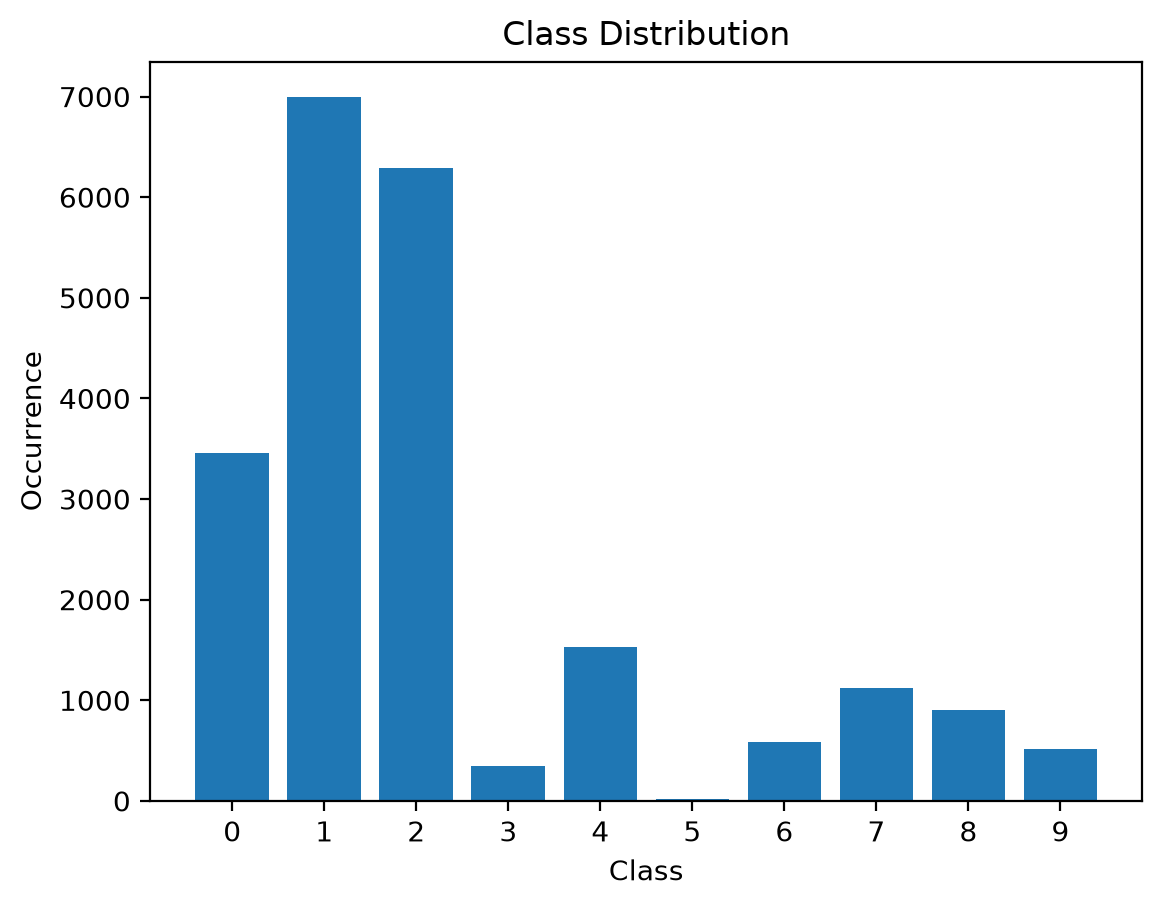

In [48]:
counts = np.bincount(labels)
plt.bar(range(len(counts)), counts)
plt.xlabel("Class")
plt.ylabel("Occurrence")
plt.xticks(range(len(counts)))
plt.title("Class Distribution")
plt.show()

In [49]:
# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# (one hot encoding)
labels

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [50]:
# # Select 10 of the images to inspect
# img = None
# plt.ion()
# print("===================Data Inspection===================")
# for counter, i in enumerate(
#     range(np.random.randint(0, labels.shape[0], size=10).shape[0])
# ):
#     img = plt.imshow(images[i])
#     plt.title(
#         f"Class {np.argmax(labels[i])}: {galaxy10cls_lookup(labels[i])} \n Random Demo images {counter+1} of 10"
#     )
#     plt.draw()
#     plt.pause(2.0)
# plt.close("all")
# print("===============Data Inspection Finished===============")

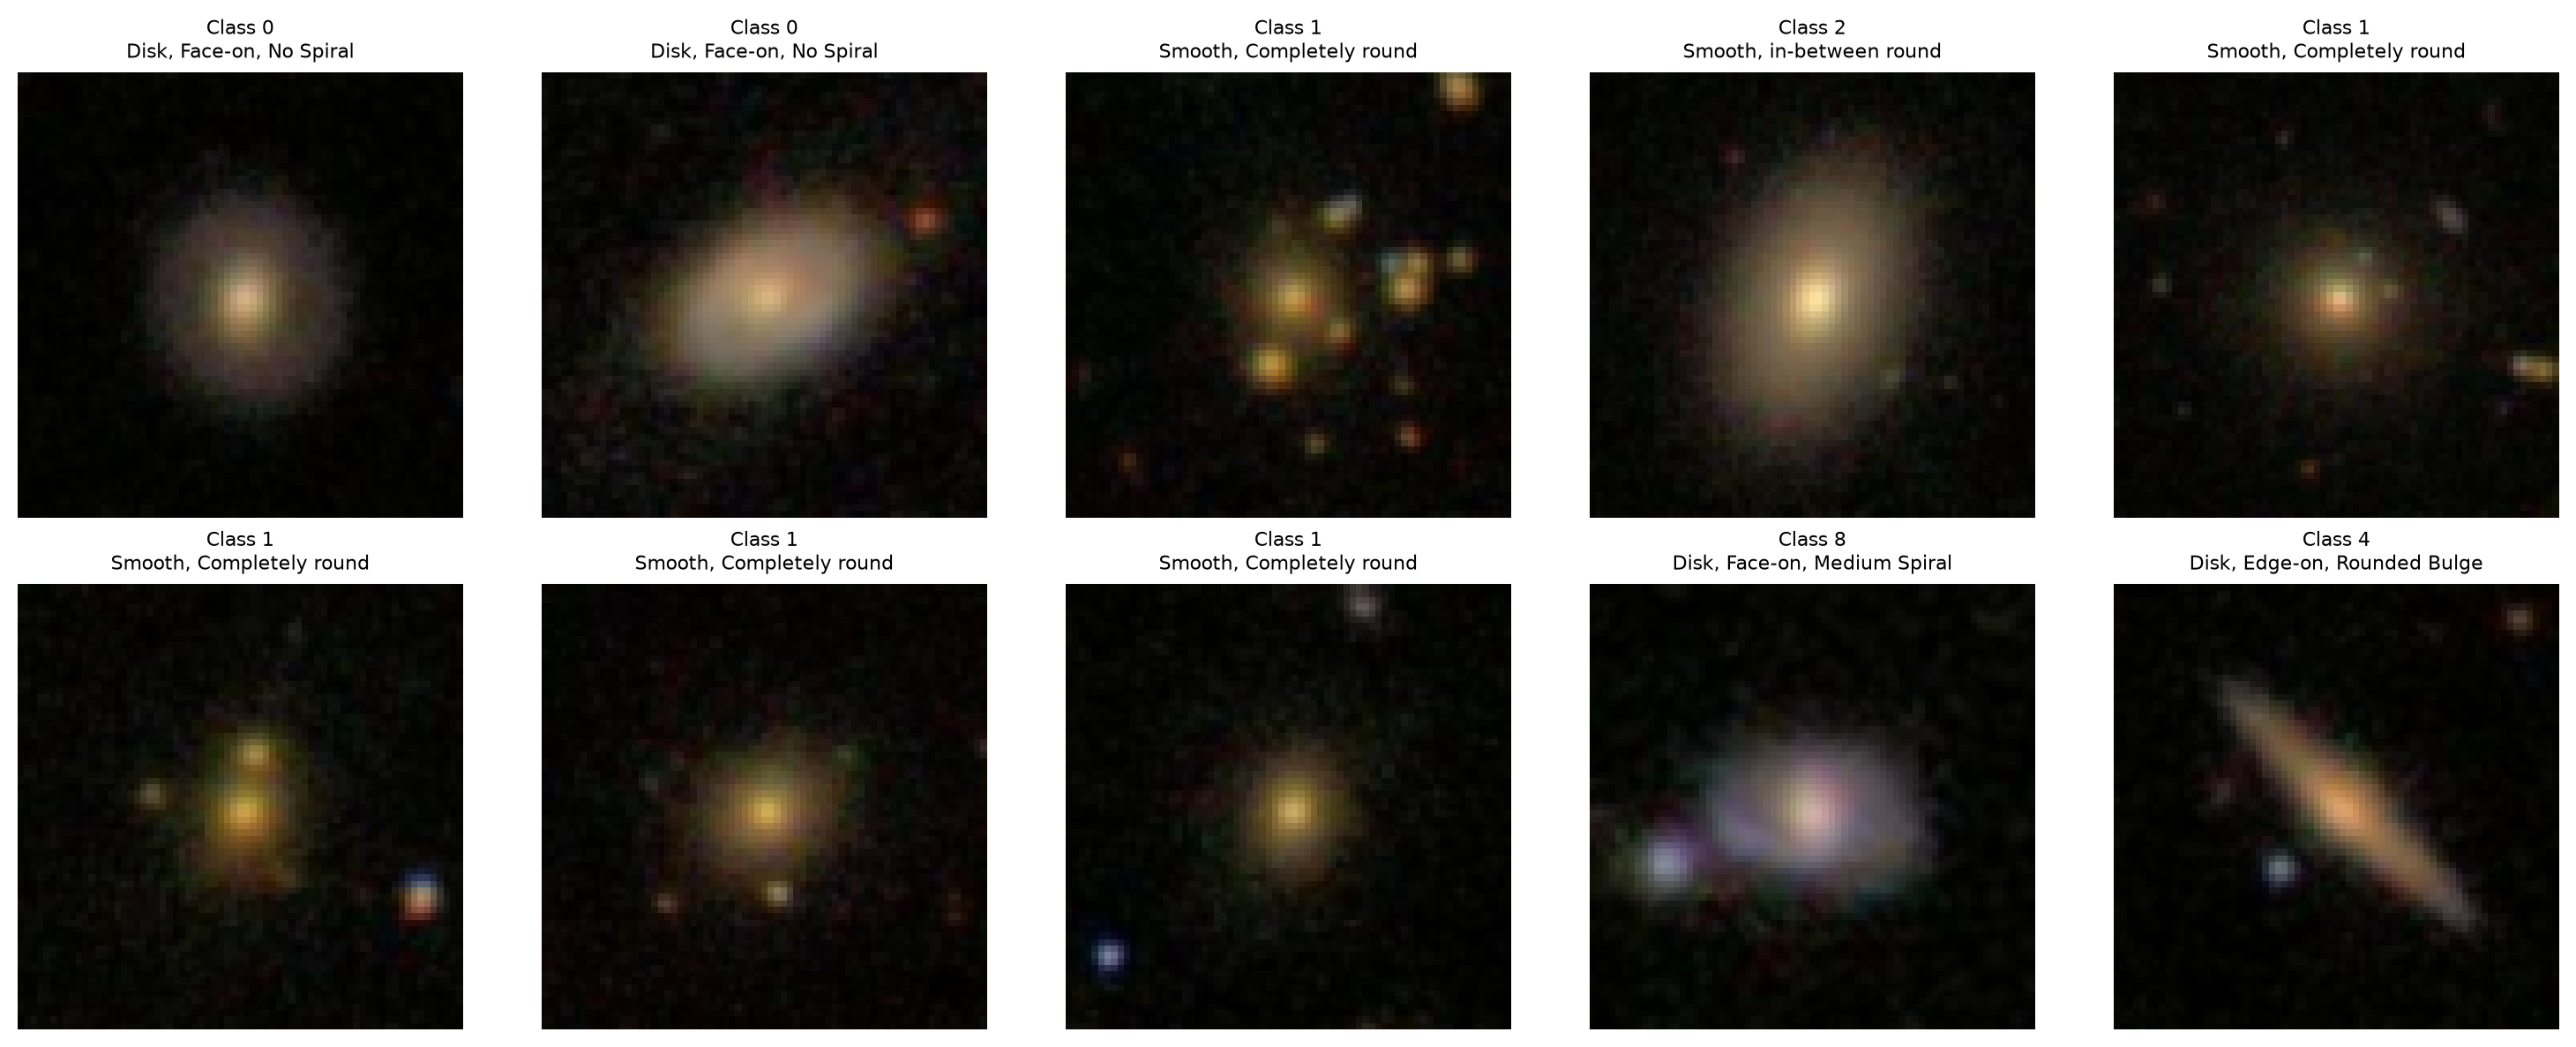

In [51]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, labels.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(images[i])
    ax.set_title(f"Class {np.argmax(labels[i])}\n{galaxy10cls_lookup(labels[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("galaxies.pdf")
plt.show()

In [52]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 69
# images_small = np.array([center_crop(img, crop_size) for img in images])
# print(images_small.shape, images_small.nbytes / 1e9, "GB")

In [53]:
from PIL import Image
import numpy as np

images_gray = np.array([
    np.array(Image.fromarray(img).convert('L')) for img in images
])

print(images_gray.shape)  

(21785, 69, 69)


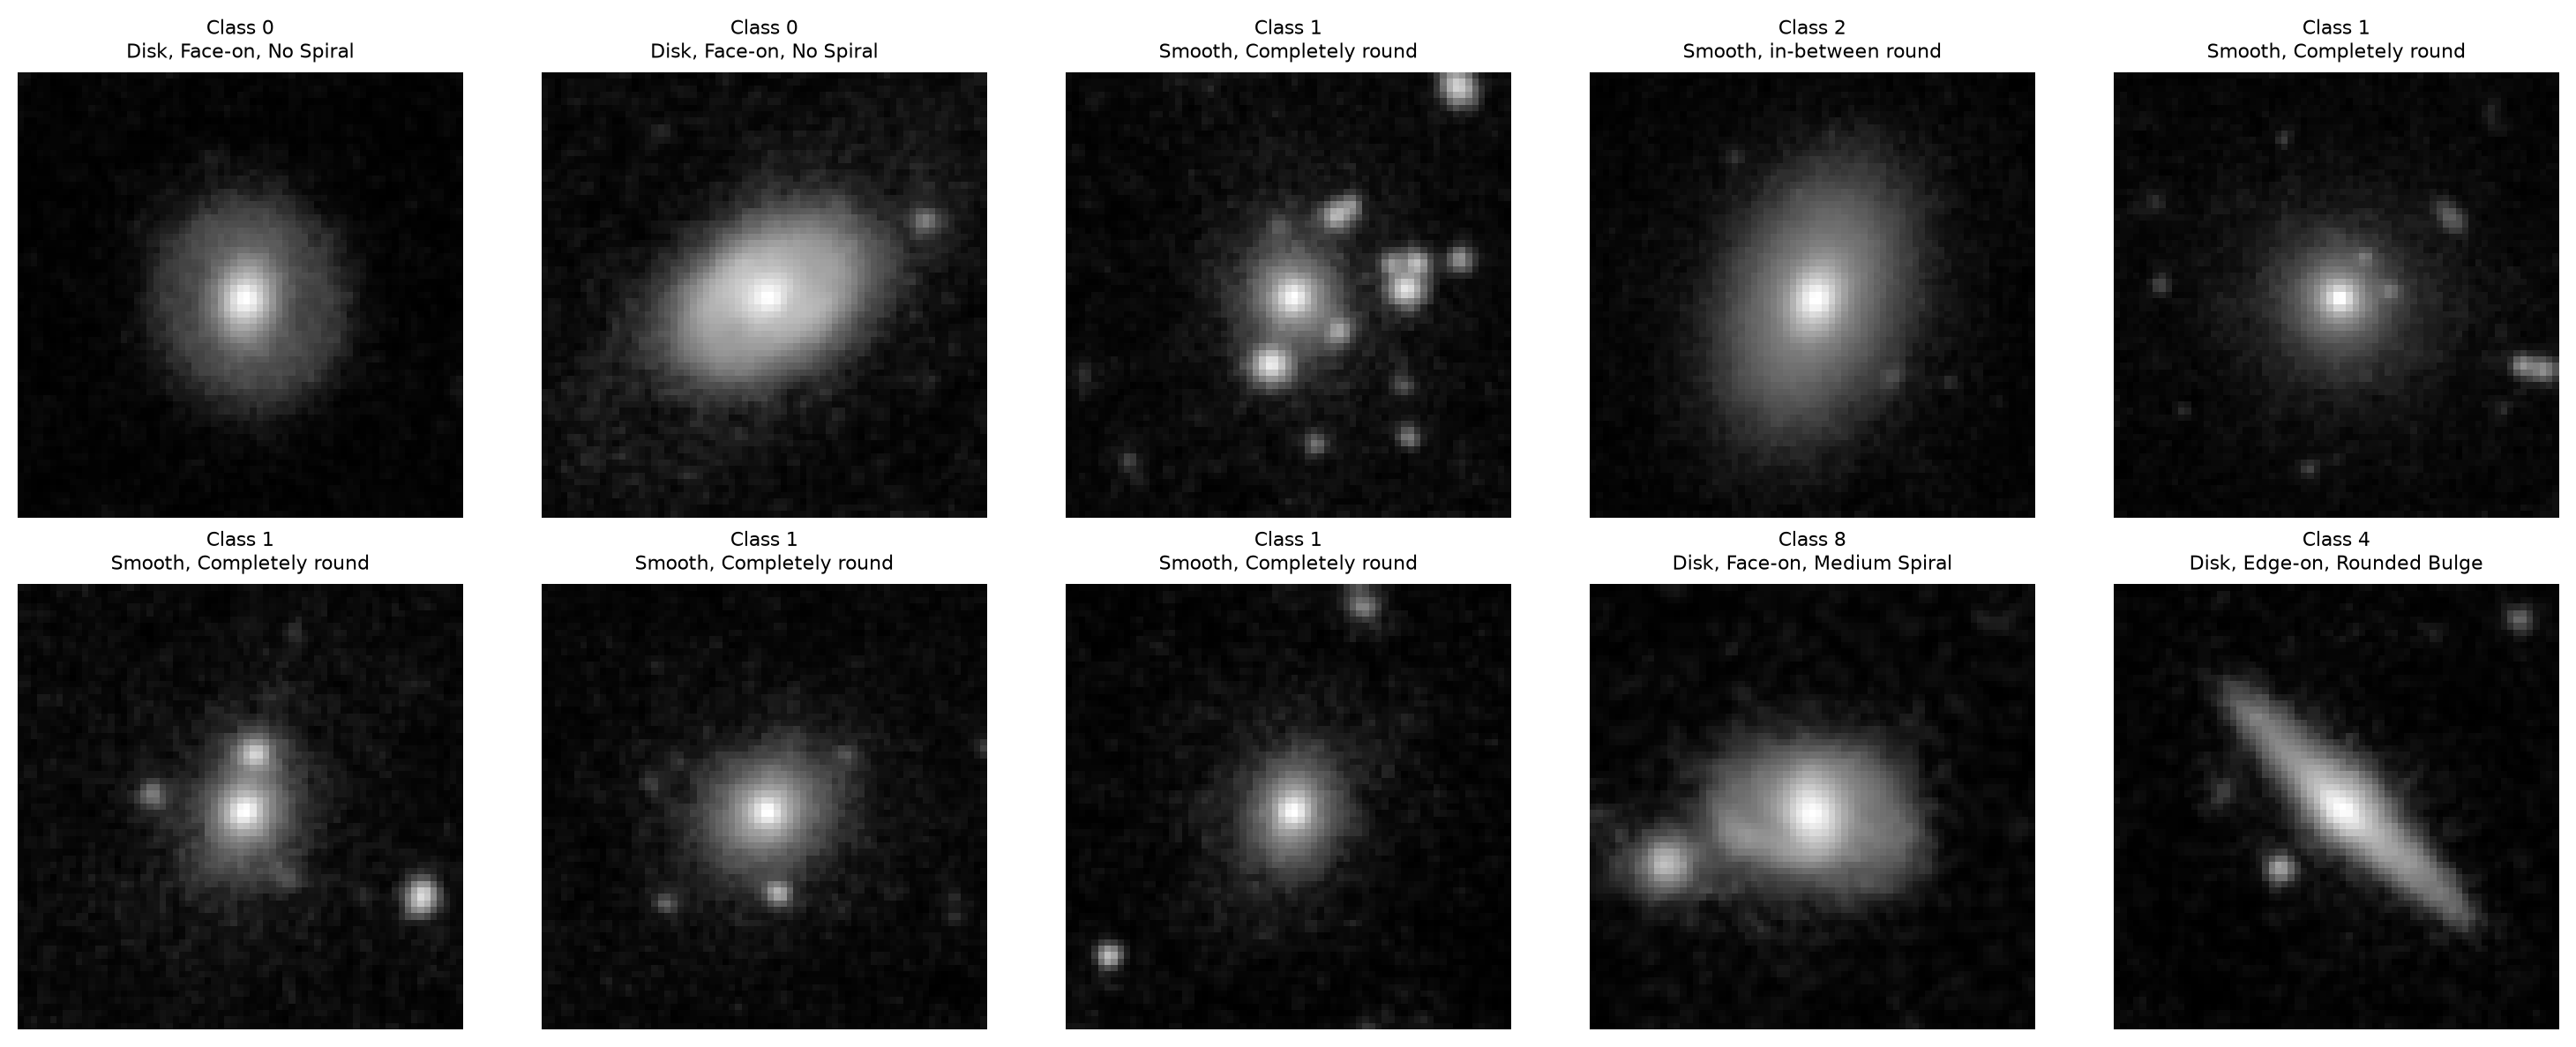

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# idx = np.random.randint(0, labels.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(images_gray[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(labels[i])}\n{galaxy10cls_lookup(labels[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [55]:
print("images shape:", images_gray.shape, images_gray.dtype)
print("labels shape:", labels.shape, labels.dtype)
print("Estimated memory (GB):", images.nbytes / 1e9)

import psutil
print("RAM available (GB):", psutil.virtual_memory().available / 1e9)
print("RAM total (GB):", psutil.virtual_memory().total / 1e9)

images shape: (21785, 69, 69) uint8
labels shape: (21785, 10) float64
Estimated memory (GB): 0.311155155
RAM available (GB): 2.129821696
RAM total (GB): 8.589934592


In [56]:
del images

In [57]:
# Split the dataset into training set and testing set
train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.1)
train_images, train_labels, test_images, test_labels = (
    images_gray[train_idx],
    labels[train_idx],
    images_gray[test_idx],
    labels[test_idx],
)

del images_gray, labels

In [58]:
train_images = train_images.astype(np.float32, copy=False)

In [59]:
train_labels = train_labels.astype(np.float32, copy=False)

In [60]:
test_images = test_images.astype(np.float32, copy=False)

In [61]:
test_labels = test_labels.astype(np.float32, copy=False)

Glaxy10CNN is a simple 4 layered convolutional neural network consisted of 2 convolutional layers and 2 dense layers

In [62]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"

# To create a neural network instance
galaxy10net = Galaxy10CNN()

# set maximium epochs the neural network can run, set 5 to get quick result
galaxy10net.max_epochs = 20

# To train the neural net
# astroNN will normalize the data by default
galaxy10net.fit(train_images, train_labels)   

# print model summary 
galaxy10net.keras_model.summary()

Number of Training Data: 17646, Number of Validation Data: 1960
====Message from Normalizer====
You selected mode: 255
Featurewise Center: {'input': False}
Datawise Center: {'input': False} 
Featurewise std Center: {'input': False}
Datawise std Center: {'input': False} 
====Message ends====
====Message from Normalizer====
You selected mode: 0
Featurewise Center: {'output': False}
Datawise Center: {'output': False} 
Featurewise std Center: {'output': False}
Datawise std Center: {'output': False} 
====Message ends====
Epoch 1/20
275/275 - 23s - 83ms/step - categorical_accuracy: 0.3738 - loss: 1.5859 - val_categorical_accuracy: 0.5198 - val_loss: 1.2786 - learning_rate: 0.0050
Epoch 2/20
275/275 - 19s - 67ms/step - categorical_accuracy: 0.5532 - loss: 1.2284 - val_categorical_accuracy: 0.6474 - val_loss: 1.0255 - learning_rate: 0.0050
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
275/275 - 24s - 87ms/step - categorical_accuracy: 0.6140 - loss: 1.1

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 69, 69, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 69, 69, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 69, 69, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 69, 69, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4624)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4624)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,184,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Activation)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,658,304 (13.96 MB)

 Trainable params: 1,219,434 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,438,870 (9.30 MB)

Prediction progress: : 2243sample [00:01, 2189.97sample/s]                                                                           


(2179,)


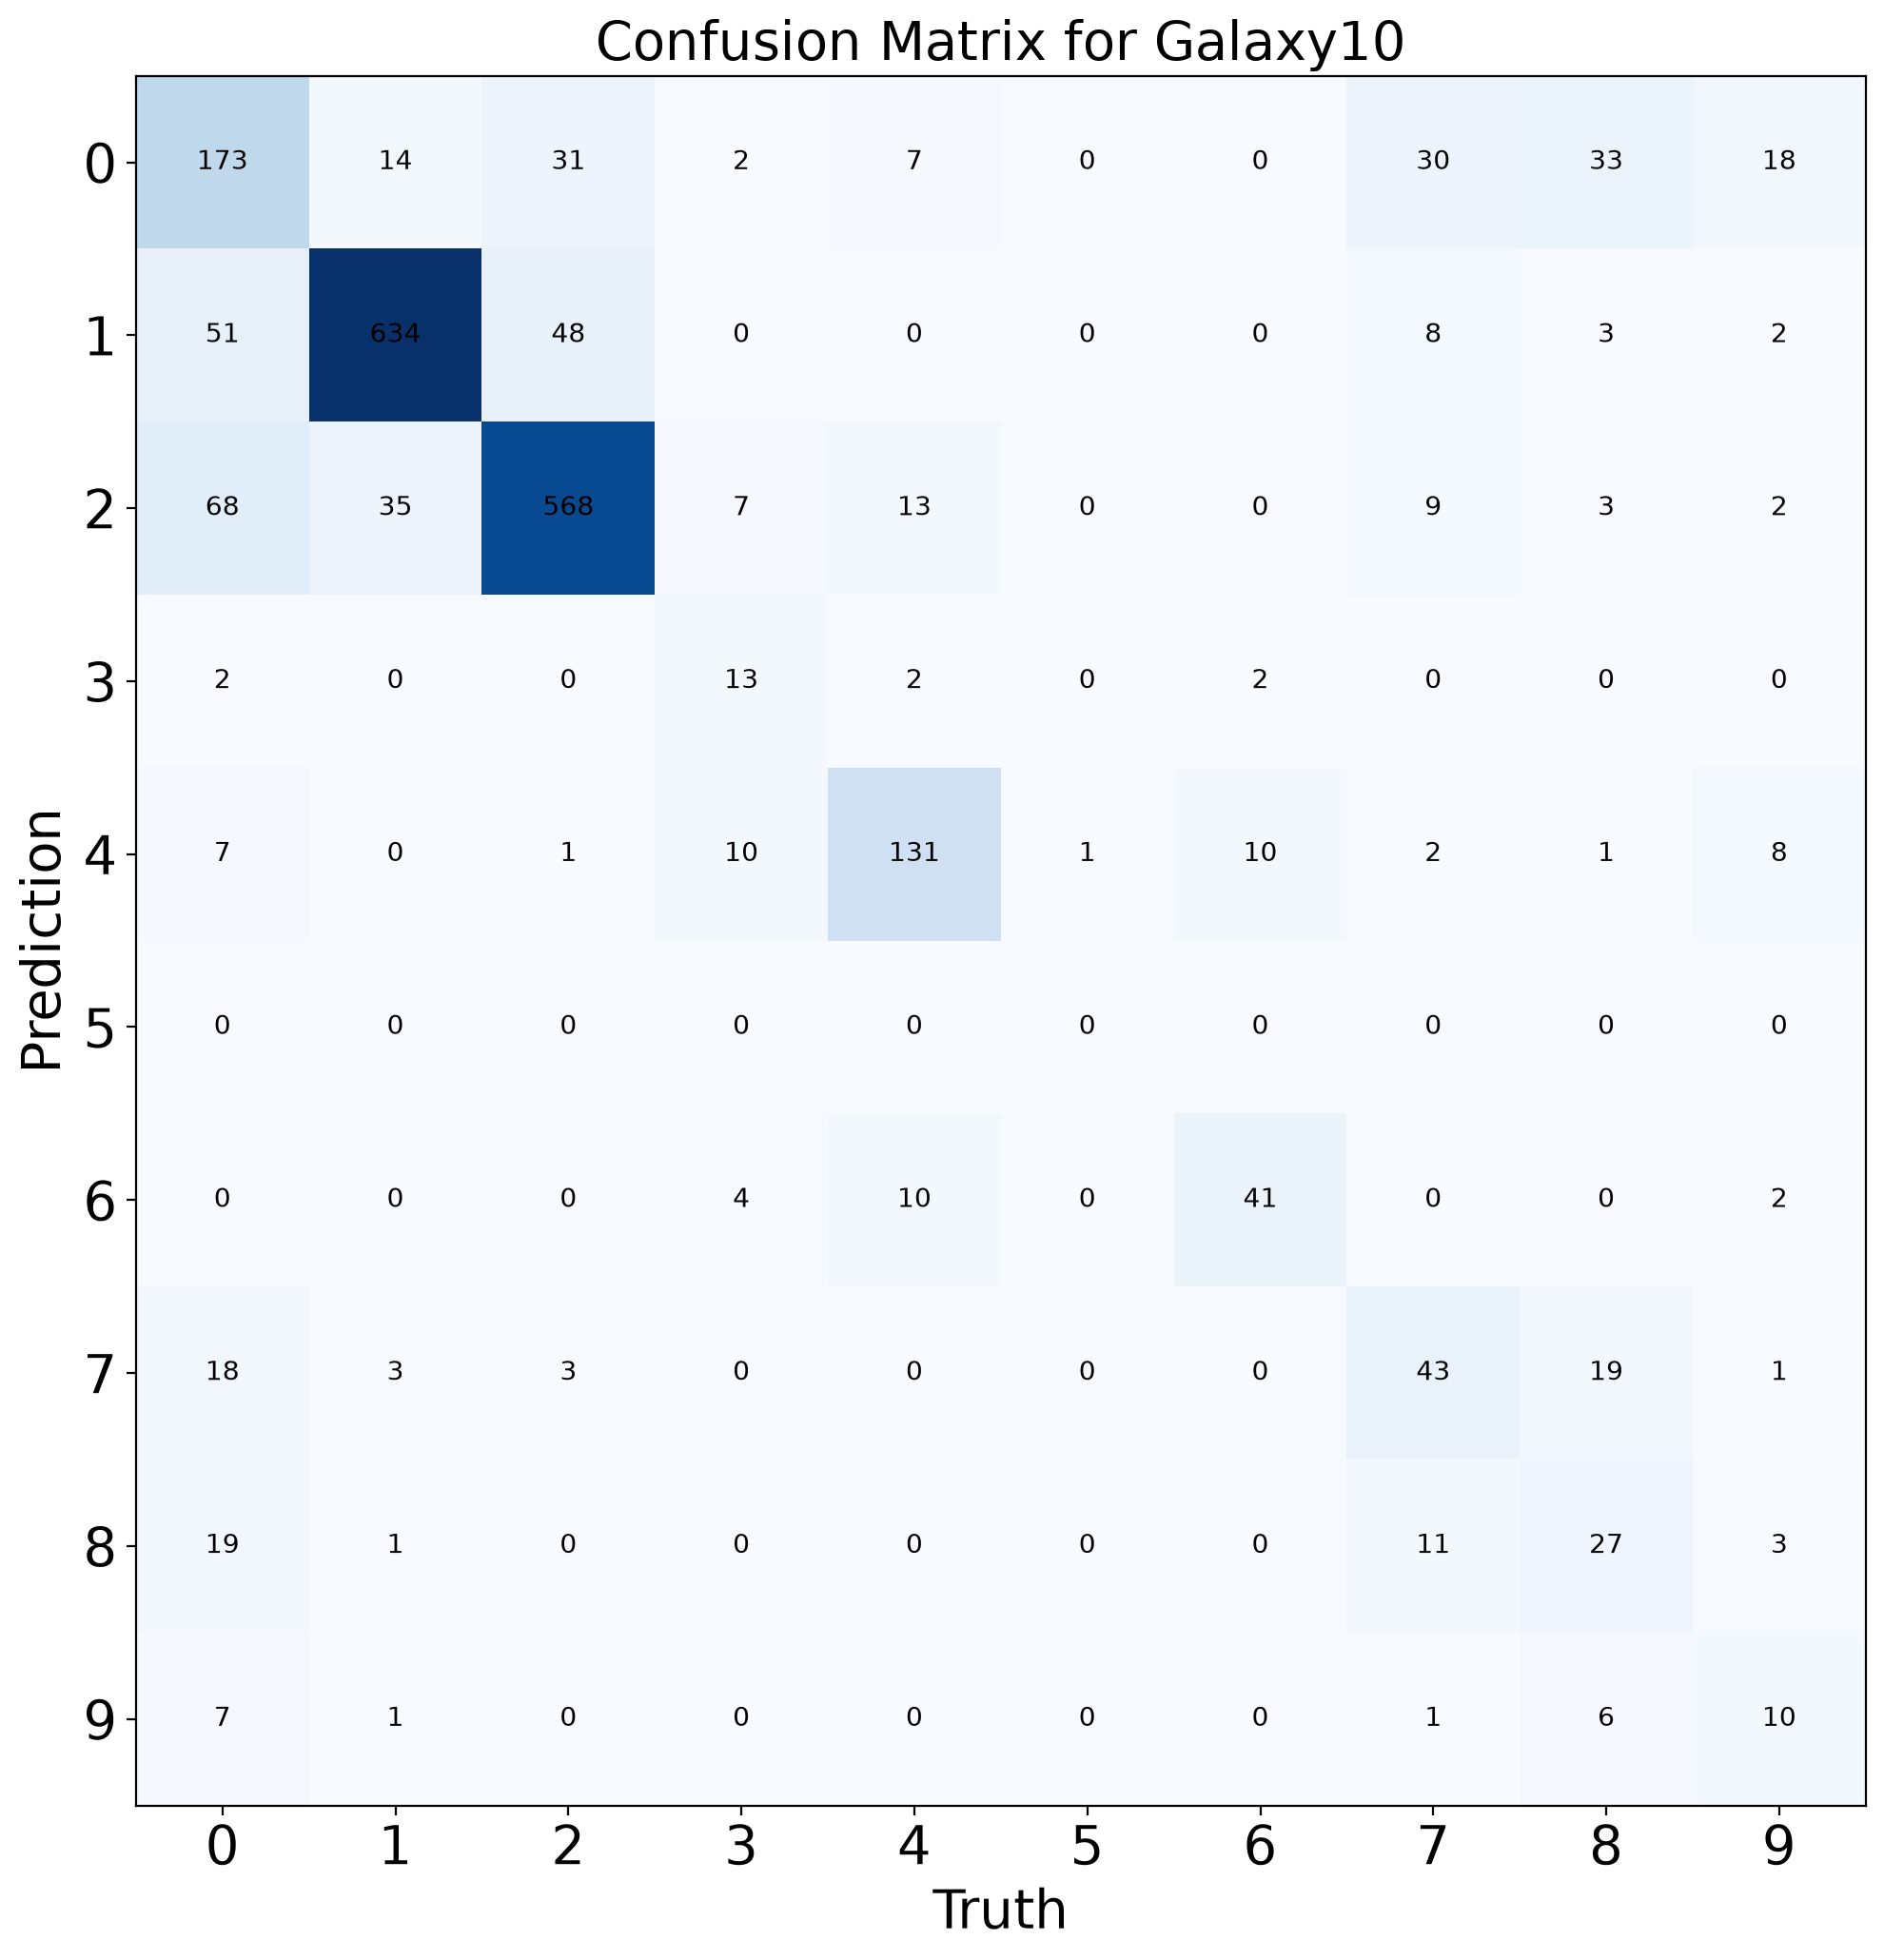

In [63]:
# After the training, you can test the neural net performance
# Please notice predicted_labels are labels predicted from neural network. test_labels are ground truth from the dataset
predicted_labels = galaxy10net.predict(test_images)

# Convert predicted_labels to class
prediction_class = np.argmax(predicted_labels, axis=1)
print(prediction_class.shape)

# Convert test_labels to class
test_class = np.argmax(test_labels, axis=1)

# Prepare a confusion matrix
confusion_matrix = np.zeros((10, 10))

# create the confusion matrix
for counter, i in enumerate(prediction_class):
    confusion_matrix[i, test_class[counter]] += 1

# Plot the confusion matrix
galaxy10_confusion(confusion_matrix)